# EXP 00 — Data Audit, Match-Level Canonicalization, Offline AW-MAE Evaluator, Temporal Validation, dan Fondasi Pipeline Kompetisi

---

## Tujuan Eksperimen

Notebook ini adalah **fondasi** untuk seluruh pipeline kompetisi prediksi skor sepak bola internasional.  
Notebook ini **bukan** tentang membangun model final, melainkan memastikan seluruh infrastruktur yang dibutuhkan sudah benar:

1. **Data Audit** — Memastikan seluruh file kompetisi terbaca dengan aman, memahami struktur kolom, tipe data, dan missing values.
2. **Match Pairing Verification** — Membuktikan bahwa satu pertandingan direpresentasikan oleh dua baris (satu per tim).
3. **Match-Level Canonicalization** — Mengubah representasi dua-baris menjadi satu baris per pertandingan yang stabil dan deterministik.
4. **Reverse Mapping** — Menyediakan helper untuk mengonversi prediksi match-level kembali ke format submission row-level.
5. **Offline AW-MAE Evaluator** — Mengimplementasikan metrik evaluasi kompetisi secara offline, termasuk penalty dan tournament weighting.
6. **Temporal Validation Split** — Menyiapkan split validasi yang leakage-safe dan realistis.
7. **Feature Feasibility Audit** — Mengidentifikasi fitur yang tersedia di train dan test vs yang hanya ada di train.
8. **Baseline Sanity Check** — Memastikan seluruh pipeline bekerja dengan prediksi sederhana.

### Mengapa Notebook Ini Penting?

- Kompetisi menggunakan **AW-MAE** yang sangat sensitif terhadap kesalahan outcome (menang/seri/kalah).
- **Train dan test memiliki feature space yang berbeda** — banyak fitur performa historis tidak tersedia di test.
- **External data tidak diperbolehkan** — semua pipeline harus menggunakan file kompetisi yang tersedia saja.
- **Validasi harus temporal** — karena test berada di rentang waktu setelah train.

## 01. Setup dan Konfigurasi

Import seluruh library yang dibutuhkan, set konfigurasi global, dan definisikan path file.

In [1]:
import os
import sys
import json
import math
import random
import warnings
import textwrap
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("[INFO] Semua library berhasil di-import.")

[INFO] Semua library berhasil di-import.


In [2]:
# === KONFIGURASI GLOBAL ===
SEED = 42

# Path file (relatif dari folder notebook/)
TRAIN_PATH = "../data/train.csv"
TEST_PATH = "../data/test.csv"
SAMPLE_SUB_PATH = "../data/sample submission.csv"
META_PATH = "../data/metadata.txt"

# Pandas display options
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 30)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 40)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
warnings.filterwarnings("ignore")

print(f"[INFO] SEED      = {SEED}")
print(f"[INFO] TRAIN     = {TRAIN_PATH}")
print(f"[INFO] TEST      = {TEST_PATH}")
print(f"[INFO] SAMPLE    = {SAMPLE_SUB_PATH}")
print(f"[INFO] METADATA  = {META_PATH}")

[INFO] SEED      = 42
[INFO] TRAIN     = ../data/train.csv
[INFO] TEST      = ../data/test.csv
[INFO] SAMPLE    = ../data/sample submission.csv
[INFO] METADATA  = ../data/metadata.txt


In [3]:
def seed_everything(seed: int = 42) -> None:
    """Set seed untuk reproducibility di seluruh library.

    Mengatur seed untuk modul random, numpy, dan PYTHONHASHSEED
    agar hasil eksperimen konsisten setiap kali notebook dijalankan.
    """
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"[INFO] Seed berhasil diset ke {seed}")

seed_everything(SEED)

[INFO] Seed berhasil diset ke 42


### Catatan Setup

- **Seed** diset ke `42` agar setiap run menghasilkan output yang identik. Ini krusial untuk eksperimen yang reproducible.
- **Path** didefinisikan secara eksplisit menggunakan path relatif karena notebook dijalankan dari folder `notebook/`.
- Library yang di-import adalah library minimal yang dibutuhkan untuk audit data dan fondasi pipeline.

## 02. Validasi File Input

Sebelum memproses data, pastikan semua file yang dibutuhkan tersedia di lokasi yang benar.  
Jika ada file yang hilang, notebook akan berhenti dengan error yang jelas.

In [4]:
FILE_PATHS = {
    "train": TRAIN_PATH,
    "test": TEST_PATH,
    "sample_submission": SAMPLE_SUB_PATH,
    "metadata": META_PATH,
}


def validate_input_files(file_paths: dict) -> None:
    """Periksa keberadaan semua file input yang dibutuhkan.

    Parameters
    ----------
    file_paths : dict
        Dictionary {nama: path} untuk semua file yang harus ada.

    Raises
    ------
    FileNotFoundError
        Jika satu atau lebih file tidak ditemukan.
    """
    missing = []
    for name, path in file_paths.items():
        if not Path(path).exists():
            missing.append((name, path))
    if missing:
        msg = "File berikut TIDAK ditemukan:\n" + "\n".join(
            f"  - {n}: {p}" for n, p in missing
        )
        raise FileNotFoundError(msg)
    print("[OK] Semua file input ditemukan.")


validate_input_files(FILE_PATHS)

[OK] Semua file input ditemukan.


In [5]:
# Cetak ukuran file
print("Ukuran file:")
print("-" * 65)
for name, path in FILE_PATHS.items():
    p = Path(path)
    size_mb = p.stat().st_size / (1024 * 1024)
    print(f"  {name:20s}  {str(p):35s}  {size_mb:8.2f} MB")

Ukuran file:
-----------------------------------------------------------------
  train                 ..\data\train.csv                       22.44 MB
  test                  ..\data\test.csv                         6.98 MB
  sample_submission     ..\data\sample submission.csv            0.91 MB
  metadata              ..\data\metadata.txt                     0.00 MB


### Hasil Validasi

Tahap ini memastikan bahwa environment dan struktur project sudah benar sebelum proses lebih lanjut.  
Jika file tidak ditemukan, pastikan notebook dijalankan dari folder `notebook/` dan folder `data/` berada di root project.

## 03. Load Data dan Metadata

Load seluruh file CSV dan metadata. Kolom `date` di-parse langsung menjadi datetime.

In [6]:
# Load CSV dengan parsing aman
train = pd.read_csv(TRAIN_PATH, parse_dates=["date"])
test = pd.read_csv(TEST_PATH, parse_dates=["date"])
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print(f"Train shape      : {train.shape}")
print(f"Test shape       : {test.shape}")
print(f"Sample sub shape : {sample_sub.shape}")

Train shape      : (78772, 47)
Test shape       : (42422, 20)
Sample sub shape : (42422, 3)


In [7]:
# Load metadata sebagai raw text
with open(META_PATH, "r", encoding="utf-8") as f:
    metadata_text = f.read()

print("=" * 60)
print("METADATA")
print("=" * 60)
print(metadata_text)

METADATA
1. Identitas & Info Dasar
Id: Identitas unik untuk setiap baris (Format: match_id_nama_tim).
match_id: ID unik untuk satu pertandingan (satu pertandingan memiliki dua baris Id untuk masing-masing tim).
date: Tanggal pertandingan dilaksanakan.
gender: Jenis kelamin pemain (M untuk Pria, W untuk Wanita).
team: Nama tim utama.
opponent: Nama tim lawan.

2. Kondisi Pertandingan
is_home: Binary (1/0), apakah tim bermain di kandang sendiri.
neutral: Binary (1/0), apakah pertandingan dimainkan di tempat netral.
tournament: Nama kompetisi atau jenis turnamen (misal: Friendly, FIFA World Cup, dll).
venue_country: Negara tempat pertandingan berlangsung.
confederation_team/opp: Konfederasi sepak bola tim/lawan (misal: UEFA, CAF, CONMEBOL).

3. Metrik Performa (Hanya tersedia lengkap di train.csv)
elo_team / elo_opponent: Peringkat Elo masing-masing tim saat pertandingan.
rank_team / rank_opponent: Peringkat FIFA masing-masing tim.
team_points_last5 / last10: Poin yang dikumpulkan dalam 5

In [8]:
# Ringkasan shape dan jumlah kolom
print(f"{'Dataset':<20s} {'Rows':>10s} {'Cols':>6s}")
print("-" * 38)
for name, df in [("Train", train), ("Test", test), ("Sample Submission", sample_sub)]:
    print(f"{name:<20s} {df.shape[0]:>10,} {df.shape[1]:>6}")

Dataset                    Rows   Cols
--------------------------------------
Train                    78,772     47
Test                     42,422     20
Sample Submission        42,422      3


In [9]:
# Head: Train
print("=== TRAIN HEAD ===")
display(train.head(3))

=== TRAIN HEAD ===


,Id,match_id,date,gender,team,opponent,is_home,neutral,tournament,venue_country,team_goals,opp_goals,team_points_last5,opp_points_last5,points_last5_diff,team_gd_last5,opp_gd_last5,gd_last5_diff,h2h_points_last5,h2h_gd_last5,days_since_last_match_team,days_since_last_match_opp,team_points_last10,opp_points_last10,team_avg_goals_last5,team_avg_conceded_last5,opp_avg_goals_last5,opp_avg_conceded_last5,team_win_rate_last10,opp_win_rate_last10,elo_team,elo_opponent,rank_team,rank_opponent,rank_diff,rank_missing_team,rank_missing_opp,confederation_team,confederation_opp,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,altitude_venue,distance_travel_team,distance_travel_opp,temperature_venue
0,M000001_Scotland,M000001,1872-11-30,M,Scotland,England,1,0,Friendly,Scotland,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.0000,1500.0000,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M000001_England,M000001,1872-11-30,M,England,Scotland,0,0,Friendly,Scotland,0,0,NaN,1.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,0.0000,NaN,1.0000,NaN,NaN,0.0000,0.0000,NaN,0.0000,1500.0000,1500.0000,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M000002_England,M000002,1873-03-08,M,England,Scotland,1,0,Friendly,England,4,2,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,98.0000,98.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1500.0000,1500.0000,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Head: Test
print("=== TEST HEAD ===")
display(test.head(3))

=== TEST HEAD ===


,Id,match_id,date,gender,team,opponent,is_home,neutral,tournament,venue_country,confederation_team,confederation_opp,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,altitude_venue,distance_travel_team,distance_travel_opp,temperature_venue
0,M034984_Seychelles,M034984,2011-08-06,M,Seychelles,Mauritius,1,0,Indian Ocean Island Games,Seychelles,CAF,CAF,92409.0000,1283330.0000,12189.0952,9197.0270,-9999.0000,0.0000,1751.8957,25.7902
1,M034984_Mauritius,M034984,2011-08-06,M,Mauritius,Seychelles,0,0,Indian Ocean Island Games,Seychelles,CAF,CAF,1283330.0000,92409.0000,9197.0270,12189.0952,-9999.0000,1751.8957,0.0000,25.7902
2,M034985_Comoros,M034985,2011-08-06,M,Comoros,Maldives,1,1,Indian Ocean Island Games,Seychelles,CAF,AFC,656024.0000,361575.0000,1447.9451,7291.4660,-9999.0000,1517.0107,5483.1175,25.7902


In [11]:
# Head: Sample Submission
print("=== SAMPLE SUBMISSION HEAD ===")
display(sample_sub.head(3))

=== SAMPLE SUBMISSION HEAD ===


,Id,team_goals,opp_goals
0,M034984_Seychelles,0,0
1,M034984_Mauritius,0,0
2,M034985_Comoros,0,0


### Ringkasan Awal

- **Train** memiliki banyak baris dan kolom, termasuk fitur performa historis dan target.
- **Test** memiliki kolom yang jauh lebih sedikit — hanya fitur dasar dan kontekstual.
- **Sample submission** memiliki jumlah baris yang sama dengan test, dengan kolom `Id`, `team_goals`, `opp_goals`.
- **Metadata** menjelaskan arti setiap kolom dalam dataset.

## 04. Audit Struktur Kolom

Bandingkan kolom train dan test untuk memahami **feature gap** antara keduanya.  
Ini krusial karena model yang hanya menggunakan fitur train-only tidak akan bisa digunakan saat inference di test.

In [12]:
# Bandingkan kolom train vs test
train_cols = set(train.columns)
test_cols = set(test.columns)

train_only = sorted(train_cols - test_cols)
test_only = sorted(test_cols - train_cols)
shared = sorted(train_cols & test_cols)

print(f"Kolom hanya di TRAIN ({len(train_only)}):")
for c in train_only:
    print(f"  - {c}")

print(f"\nKolom hanya di TEST ({len(test_only)}):")
for c in test_only:
    print(f"  - {c}")

print(f"\nKolom yang ada di KEDUANYA ({len(shared)}):")
for c in shared:
    print(f"  - {c}")

Kolom hanya di TRAIN (27):
  - days_since_last_match_opp
  - days_since_last_match_team
  - elo_opponent
  - elo_team
  - gd_last5_diff
  - h2h_gd_last5
  - h2h_points_last5
  - opp_avg_conceded_last5
  - opp_avg_goals_last5
  - opp_gd_last5
  - opp_goals
  - opp_points_last10
  - opp_points_last5
  - opp_win_rate_last10
  - points_last5_diff
  - rank_diff
  - rank_missing_opp
  - rank_missing_team
  - rank_opponent
  - rank_team
  - team_avg_conceded_last5
  - team_avg_goals_last5
  - team_gd_last5
  - team_goals
  - team_points_last10
  - team_points_last5
  - team_win_rate_last10

Kolom hanya di TEST (0):

Kolom yang ada di KEDUANYA (20):
  - Id
  - altitude_venue
  - confederation_opp
  - confederation_team
  - date
  - distance_travel_opp
  - distance_travel_team
  - gdp_per_capita_opp
  - gdp_per_capita_team
  - gender
  - is_home
  - match_id
  - neutral
  - opponent
  - population_opp
  - population_team
  - team
  - temperature_venue
  - tournament
  - venue_country


In [13]:
# Tabel audit kolom lengkap
all_cols = sorted(train_cols | test_cols)
col_audit_rows = []
for c in all_cols:
    col_audit_rows.append({
        "column_name": c,
        "in_train": c in train_cols,
        "in_test": c in test_cols,
        "dtype_train": str(train[c].dtype) if c in train_cols else "-",
        "dtype_test": str(test[c].dtype) if c in test_cols else "-",
    })

col_audit_df = pd.DataFrame(col_audit_rows)
display(col_audit_df)

,column_name,in_train,in_test,dtype_train,dtype_test
0,Id,True,True,str,str
1,altitude_venue,True,True,float64,float64
2,confederation_opp,True,True,str,str
3,confederation_team,True,True,str,str
4,date,True,True,datetime64[us],datetime64[us]
...,...,...,...,...,...
42,team_points_last5,True,False,float64,-
43,team_win_rate_last10,True,False,float64,-
44,temperature_venue,True,True,float64,float64
45,tournament,True,True,str,str


In [14]:
# Identifikasi target columns
TARGET_COLS = ["team_goals", "opp_goals"]
print("Verifikasi target columns:")
for tc in TARGET_COLS:
    in_train = tc in train.columns
    in_test = tc in test.columns
    status = "OK" if (in_train and not in_test) else "MASALAH"
    print(f"  {tc}: in_train={in_train}, in_test={in_test}  [{status}]")

assert all(tc in train.columns for tc in TARGET_COLS), "Target tidak ditemukan di train!"
assert all(tc not in test.columns for tc in TARGET_COLS), "Target ditemukan di test — potensi leak!"
print("\n[OK] Target columns terverifikasi: ada di train, tidak ada di test.")

Verifikasi target columns:
  team_goals: in_train=True, in_test=False  [OK]
  opp_goals: in_train=True, in_test=False  [OK]

[OK] Target columns terverifikasi: ada di train, tidak ada di test.


### Insight Penting: Feature Gap Train vs Test

- **Train** memiliki **fitur performa historis** yang kaya: Elo rating, FIFA ranking, form (last 5/10 matches), head-to-head, win rate, dll.
- **Test** hanya memiliki fitur **identitas, kondisi pertandingan, geografis, dan sosio-ekonomi**.
- Ini berarti:
  - Eksperimen berikutnya **harus berhati-hati** agar tidak membangun pipeline yang bergantung penuh pada fitur train-only.
  - Model baseline awal harus feasible hanya dengan **shared features**.
  - Fitur train-only bisa dipertimbangkan melalui feature engineering kreatif di eksperimen lanjutan.
- **Ini adalah salah satu tantangan inti kompetisi.**

## 05. Audit Tipe Data dan Missing Values

Periksa tipe data setiap kolom dan identifikasi missing values pada train dan test.

In [15]:
def summarize_dataframe(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Buat ringkasan tipe data, non-null count, dan unique values untuk sebuah DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame yang ingin diringkas.
    name : str
        Label untuk ditampilkan.

    Returns
    -------
    pd.DataFrame
        Tabel ringkasan.
    """
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": [str(d) for d in df.dtypes.values],
        "non_null": df.notnull().sum().values,
        "null_count": df.isnull().sum().values,
        "null_pct": (df.isnull().sum().values / len(df) * 100).round(2),
        "n_unique": df.nunique().values,
    })
    print(f"{'=' * 60}")
    print(f"Ringkasan: {name} ({df.shape[0]:,} rows × {df.shape[1]} cols)")
    print(f"{'=' * 60}")
    return summary


train_summary = summarize_dataframe(train, "Train")
display(train_summary)

Ringkasan: Train (78,772 rows × 47 cols)


,column,dtype,non_null,null_count,null_pct,n_unique
0,Id,str,78772,0,0.0000,78772
1,match_id,str,78772,0,0.0000,39386
2,date,datetime64[us],78772,0,0.0000,14881
3,gender,str,78772,0,0.0000,2
4,team,str,78772,0,0.0000,294
...,...,...,...,...,...,...
42,gdp_per_capita_opp,float64,52815,25957,32.9500,5562
43,altitude_venue,float64,58218,20554,26.0900,130
44,distance_travel_team,float64,48380,30392,38.5800,2660
45,distance_travel_opp,float64,48380,30392,38.5800,2660


In [16]:
# Missing values: Train
train_missing = train.isnull().sum()
train_missing_pct = (train.isnull().sum() / len(train) * 100).round(2)
missing_train_df = pd.DataFrame({
    "missing_count": train_missing,
    "missing_pct": train_missing_pct,
}).sort_values("missing_pct", ascending=False)

print("=== Missing Values: TRAIN ===")
display(missing_train_df[missing_train_df["missing_count"] > 0])

=== Missing Values: TRAIN ===


,missing_count,missing_pct
rank_diff,43902,55.7300
rank_team,41946,53.2500
rank_opponent,41946,53.2500
distance_travel_opp,30392,38.5800
distance_travel_team,30392,38.5800
gdp_per_capita_opp,25957,32.9500
gdp_per_capita_team,25957,32.9500
altitude_venue,20554,26.0900
temperature_venue,17074,21.6800
population_team,14872,18.8800


In [17]:
# Missing values: Test
test_missing = test.isnull().sum()
test_missing_pct = (test.isnull().sum() / len(test) * 100).round(2)
missing_test_df = pd.DataFrame({
    "missing_count": test_missing,
    "missing_pct": test_missing_pct,
}).sort_values("missing_pct", ascending=False)

print("=== Missing Values: TEST ===")
display(missing_test_df[missing_test_df["missing_count"] > 0])

=== Missing Values: TEST ===


,missing_count,missing_pct
distance_travel_opp,16975,40.0100
distance_travel_team,16975,40.0100
gdp_per_capita_opp,14664,34.5700
gdp_per_capita_team,14664,34.5700
altitude_venue,10906,25.7100
temperature_venue,5594,13.1900
population_opp,3372,7.9500
population_team,3372,7.9500


In [18]:
# Audit sentinel value: altitude_venue == -9999
SENTINEL_VALUE = -9999

for name, df in [("Train", train), ("Test", test)]:
    if "altitude_venue" in df.columns:
        sentinel_count = (df["altitude_venue"] == SENTINEL_VALUE).sum()
        total = len(df)
        pct = sentinel_count / total * 100
        print(f"Sentinel ({SENTINEL_VALUE}) di {name}['altitude_venue']: "
              f"{sentinel_count:,} rows ({pct:.1f}%)")
    else:
        print(f"Kolom 'altitude_venue' tidak ada di {name}")

Sentinel (-9999) di Train['altitude_venue']: 766 rows (1.0%)
Sentinel (-9999) di Test['altitude_venue']: 296 rows (0.7%)


In [19]:
# Top 10 kolom dengan missing terbanyak
print("=== Top 10 Missing: TRAIN ===")
display(missing_train_df.head(10))
print("\n=== Top 10 Missing: TEST ===")
display(missing_test_df.head(10))

=== Top 10 Missing: TRAIN ===


,missing_count,missing_pct
rank_diff,43902,55.7300
rank_team,41946,53.2500
rank_opponent,41946,53.2500
distance_travel_opp,30392,38.5800
distance_travel_team,30392,38.5800
gdp_per_capita_opp,25957,32.9500
gdp_per_capita_team,25957,32.9500
altitude_venue,20554,26.0900
temperature_venue,17074,21.6800
population_team,14872,18.8800



=== Top 10 Missing: TEST ===


,missing_count,missing_pct
distance_travel_opp,16975,40.0100
distance_travel_team,16975,40.0100
gdp_per_capita_opp,14664,34.5700
gdp_per_capita_team,14664,34.5700
altitude_venue,10906,25.7100
temperature_venue,5594,13.1900
population_opp,3372,7.9500
population_team,3372,7.9500
gender,0,0.0000
date,0,0.0000


### Insight Missing Values

- Beberapa fitur **geografis dan sosio-ekonomi** memiliki missing values (population, GDP, altitude, distance, temperature).
- Fitur **rank dan Elo** juga memiliki missing, terutama untuk pertandingan historis yang sangat lama.
- Terdapat **sentinel value `-9999`** pada `altitude_venue` yang perlu ditangani sebagai missing di eksperimen lanjutan — di sini hanya diaudit, belum di-overwrite.
- Performance features (train-only) juga memiliki missing values yang signifikan.

## 06. Audit Uniqueness, Match Pairing, dan Konsistensi Dua Baris per Pertandingan

Memastikan bahwa satu pertandingan benar-benar direpresentasikan oleh dua row, dan relasi row antar tim konsisten.

In [20]:
# Uniqueness check
print(f"Train — Id unique     : {train['Id'].nunique():,} / {len(train):,}")
print(f"Train — match_id unique: {train['match_id'].nunique():,}")
print(f"Test  — Id unique     : {test['Id'].nunique():,} / {len(test):,}")
print(f"Test  — match_id unique: {test['match_id'].nunique():,}")

# Distribusi row per match_id
train_match_counts = train.groupby("match_id").size()
test_match_counts = test.groupby("match_id").size()

print(f"\nDistribusi rows per match_id (Train):")
print(train_match_counts.value_counts().sort_index().to_string())
print(f"\nDistribusi rows per match_id (Test):")
print(test_match_counts.value_counts().sort_index().to_string())

Train — Id unique     : 78,772 / 78,772
Train — match_id unique: 39,386
Test  — Id unique     : 42,422 / 42,422
Test  — match_id unique: 21,211

Distribusi rows per match_id (Train):
2    39386

Distribusi rows per match_id (Test):
2    21211


In [21]:
# match_id yang tidak punya tepat 2 rows
bad_train = train_match_counts[train_match_counts != 2]
bad_test = test_match_counts[test_match_counts != 2]

print(f"Train — match_id dengan != 2 rows: {len(bad_train)}")
print(f"Test  — match_id dengan != 2 rows: {len(bad_test)}")

if len(bad_train) > 0:
    print("\nContoh (Train):")
    display(bad_train.head(10))
if len(bad_test) > 0:
    print("\nContoh (Test):")
    display(bad_test.head(10))

Train — match_id dengan != 2 rows: 0
Test  — match_id dengan != 2 rows: 0


In [22]:
# Contoh pasangan rows untuk beberapa match_id
COLS_TO_SHOW = ["Id", "match_id", "date", "team", "opponent",
                "is_home", "neutral", "tournament", "venue_country"]
if "team_goals" in train.columns:
    COLS_TO_SHOW += ["team_goals", "opp_goals"]

sample_match_ids = train["match_id"].unique()[:3]
for mid in sample_match_ids:
    print(f"\n--- match_id: {mid} ---")
    display(train[train["match_id"] == mid][COLS_TO_SHOW])


--- match_id: M000001 ---


,Id,match_id,date,team,opponent,is_home,neutral,tournament,venue_country,team_goals,opp_goals
0,M000001_Scotland,M000001,1872-11-30,Scotland,England,1,0,Friendly,Scotland,0,0
1,M000001_England,M000001,1872-11-30,England,Scotland,0,0,Friendly,Scotland,0,0



--- match_id: M000002 ---


,Id,match_id,date,team,opponent,is_home,neutral,tournament,venue_country,team_goals,opp_goals
2,M000002_England,M000002,1873-03-08,England,Scotland,1,0,Friendly,England,4,2
3,M000002_Scotland,M000002,1873-03-08,Scotland,England,0,0,Friendly,England,2,4



--- match_id: M000003 ---


,Id,match_id,date,team,opponent,is_home,neutral,tournament,venue_country,team_goals,opp_goals
4,M000003_Scotland,M000003,1874-03-07,Scotland,England,1,0,Friendly,Scotland,2,1
5,M000003_England,M000003,1874-03-07,England,Scotland,0,0,Friendly,Scotland,1,2


In [23]:
def audit_match_pairing(df: pd.DataFrame, is_train: bool = True) -> dict:
    """Audit konsistensi representasi 2-baris-per-pertandingan.

    Memeriksa secara vektorial bahwa team/opponent swap,
    tanggal, turnamen, venue, dan skor (train) konsisten.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame row-level (train atau test).
    is_train : bool
        Jika True, periksa juga konsistensi skor.

    Returns
    -------
    dict
        Hasil audit dengan kunci 'total_matches', 'issues'.
    """
    results = {"total_matches": 0, "issues": []}

    # Cek jumlah rows per match
    counts = df.groupby("match_id").size()
    results["total_matches"] = len(counts)

    bad_counts = counts[counts != 2]
    if len(bad_counts) > 0:
        results["issues"].append(
            f"{len(bad_counts)} match_id tidak memiliki tepat 2 rows"
        )
        return results

    # Sort by match_id dan Id untuk pairing deterministik
    df_sorted = df.sort_values(["match_id", "Id"]).reset_index(drop=True)
    r1 = df_sorted.iloc[0::2].reset_index(drop=True)
    r2 = df_sorted.iloc[1::2].reset_index(drop=True)

    # Verifikasi match_id alignment
    assert (r1["match_id"].values == r2["match_id"].values).all(), \
        "match_id alignment gagal setelah sort!"

    # 1. Team/Opponent swap
    team_opp = (r1["team"].values == r2["opponent"].values)
    if not team_opp.all():
        n = (~team_opp).sum()
        results["issues"].append(f"r1.team != r2.opponent: {n} matches")

    opp_team = (r1["opponent"].values == r2["team"].values)
    if not opp_team.all():
        n = (~opp_team).sum()
        results["issues"].append(f"r1.opponent != r2.team: {n} matches")

    # 2. Tanggal
    date_ok = (r1["date"].values == r2["date"].values)
    if not date_ok.all():
        n = (~date_ok).sum()
        results["issues"].append(f"date mismatch: {n} matches")

    # 3. Tournament
    tourn_ok = (r1["tournament"].values == r2["tournament"].values)
    if not tourn_ok.all():
        n = (~tourn_ok).sum()
        results["issues"].append(f"tournament mismatch: {n} matches")

    # 4. Venue country
    venue_ok = (r1["venue_country"].values == r2["venue_country"].values)
    if not venue_ok.all():
        n = (~venue_ok).sum()
        results["issues"].append(f"venue_country mismatch: {n} matches")

    # 5. Skor (train only)
    if is_train and "team_goals" in df.columns:
        g1 = (r1["team_goals"].values == r2["opp_goals"].values)
        if not g1.all():
            n = (~g1).sum()
            results["issues"].append(f"r1.team_goals != r2.opp_goals: {n} matches")
        g2 = (r1["opp_goals"].values == r2["team_goals"].values)
        if not g2.all():
            n = (~g2).sum()
            results["issues"].append(f"r1.opp_goals != r2.team_goals: {n} matches")

    # 6. is_home di venue non-neutral
    if "is_home" in df.columns and "neutral" in df.columns:
        non_neutral = r1["neutral"].values == 0
        both_home = (r1["is_home"].values == 1) & (r2["is_home"].values == 1)
        bad_home = (non_neutral & both_home).sum()
        if bad_home > 0:
            results["issues"].append(
                f"Kedua tim home di venue non-neutral: {bad_home} matches"
            )

    if not results["issues"]:
        results["issues"].append("[OK] Semua pasangan match konsisten!")

    return results


# Audit Train
print("=" * 50)
print("AUDIT PAIRING: TRAIN")
print("=" * 50)
train_audit = audit_match_pairing(train, is_train=True)
print(f"Total matches: {train_audit['total_matches']:,}")
for issue in train_audit["issues"]:
    print(f"  {issue}")

# Audit Test
print(f"\n{'=' * 50}")
print("AUDIT PAIRING: TEST")
print("=" * 50)
test_audit = audit_match_pairing(test, is_train=False)
print(f"Total matches: {test_audit['total_matches']:,}")
for issue in test_audit["issues"]:
    print(f"  {issue}")

AUDIT PAIRING: TRAIN
Total matches: 39,386
  [OK] Semua pasangan match konsisten!

AUDIT PAIRING: TEST
Total matches: 21,211
  [OK] Semua pasangan match konsisten!


### Hasil Audit Match Pairing

- Setiap `match_id` direpresentasikan oleh **tepat 2 rows** — satu untuk setiap tim.
- Kolom identitas (team/opponent, date, tournament, venue) **konsisten** antar pasangan.
- Skor terverifikasi: `r1.team_goals == r2.opp_goals` dan sebaliknya.
- Representasi match-level dibutuhkan agar:
  - Modeling dapat dilakukan secara joint (prediksi skor kedua tim sekaligus).
  - Split temporal dilakukan per pertandingan, bukan per row.
  - Evaluasi custom metric AW-MAE dilakukan secara benar.
  - Post-processing pasangan skor lebih terkontrol.

## 07. Match-Level Canonicalization

Ini adalah **section paling penting** di notebook ini.

### Tujuan
Mengubah data row-level (2 baris per pertandingan) menjadi **satu baris match-level** yang:
- **Stabil** — hasil selalu sama untuk input yang sama
- **Deterministik** — menggunakan aturan pengurutan yang eksplisit
- **Reversible** — dapat dibalik ke format submission

### Aturan Canonical
- **`team_a`** = tim dengan nama alfabet lebih awal
- **`team_b`** = tim dengan nama alfabet lebih akhir
- Semua kolom tim mengikuti suffix `_a` dan `_b`
- Kolom match-level (date, tournament, venue, dll.) tidak di-suffix

Aturan ini memastikan bahwa untuk pertandingan "Argentina vs Brazil", `team_a` selalu "Argentina" dan `team_b` selalu "Brazil", apapun urutan baris aslinya.

In [24]:
def build_match_level(df: pd.DataFrame, is_train: bool) -> pd.DataFrame:
    """Konversi DataFrame row-level (2 rows/match) menjadi match-level (1 row/match).

    Canonical ordering: team_a = tim dengan nama alfabet lebih awal.
    Kolom di-mapping dari perspektif masing-masing row:
      - row_a (tim alfabet pertama) → suffix _a
      - row_b (tim alfabet kedua)  → suffix _b

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame row-level (train atau test).
    is_train : bool
        Jika True, termasuk kolom target (team_goals, opp_goals).

    Returns
    -------
    pd.DataFrame
        DataFrame match-level, satu baris per match_id.
    """
    # --- Validasi: pastikan tepat 2 rows per match ---
    counts = df.groupby("match_id").size()
    bad = counts[counts != 2]
    if len(bad) > 0:
        raise ValueError(
            f"{len(bad)} match_id tidak punya tepat 2 rows. "
            f"Contoh: {dict(bad.head(3))}"
        )

    # --- Sort by match_id kemudian team (alfabet) untuk canonical ordering ---
    df_sorted = df.sort_values(["match_id", "team"]).reset_index(drop=True)

    # Baris genap = row_a (alfabet pertama), baris ganjil = row_b
    row_a = df_sorted.iloc[0::2].reset_index(drop=True)
    row_b = df_sorted.iloc[1::2].reset_index(drop=True)

    # Verifikasi alignment
    assert (row_a["match_id"].values == row_b["match_id"].values).all(), \
        "Alignment match_id gagal antara row_a dan row_b!"

    result = pd.DataFrame()

    # --- Kolom match-level (shared, tidak di-suffix) ---
    match_level_cols = ["match_id", "date", "gender", "tournament",
                        "venue_country", "neutral"]
    for col in match_level_cols:
        if col in df.columns:
            result[col] = row_a[col].values

    # --- Kolom venue (shared) ---
    venue_cols = ["altitude_venue", "temperature_venue"]
    for col in venue_cols:
        if col in df.columns:
            result[col] = row_a[col].values

    # --- Identitas tim ---
    result["team_a"] = row_a["team"].values
    result["team_b"] = row_b["team"].values

    if "is_home" in df.columns:
        result["team_a_is_home"] = row_a["is_home"].values
        result["team_b_is_home"] = row_b["is_home"].values

    # --- Kolom simetris team/opp → _a / _b ---
    # Mapping: kolom asli _team → suffix baru
    symmetric_team_cols = {
        "confederation_team": "confederation",
        "population_team": "population",
        "gdp_per_capita_team": "gdp_per_capita",
        "distance_travel_team": "distance_travel",
    }
    for orig, suffix in symmetric_team_cols.items():
        if orig in df.columns:
            result[f"team_a_{suffix}"] = row_a[orig].values
            result[f"team_b_{suffix}"] = row_b[orig].values

    # --- Target (train only) ---
    if is_train and "team_goals" in df.columns and "opp_goals" in df.columns:
        result["team_a_goals"] = row_a["team_goals"].values
        result["team_b_goals"] = row_a["opp_goals"].values

    # --- Fitur performa train-only ---
    # Kolom perspektif "tim sendiri"
    perf_team_cols = {
        "elo_team": "elo",
        "rank_team": "rank",
        "rank_missing_team": "rank_missing",
        "team_points_last5": "points_last5",
        "team_gd_last5": "gd_last5",
        "team_points_last10": "points_last10",
        "team_avg_goals_last5": "avg_goals_last5",
        "team_avg_conceded_last5": "avg_conceded_last5",
        "team_win_rate_last10": "win_rate_last10",
        "days_since_last_match_team": "days_since_last_match",
    }
    for orig, suffix in perf_team_cols.items():
        if orig in df.columns:
            result[f"team_a_{suffix}"] = row_a[orig].values
            result[f"team_b_{suffix}"] = row_b[orig].values

    # Kolom perspektif "lawan" — diambil dari row masing-masing
    perf_opp_cols = {
        "elo_opponent": "opp_elo",
        "rank_opponent": "opp_rank",
        "rank_missing_opp": "opp_rank_missing",
        "opp_points_last5": "opp_points_last5",
        "opp_gd_last5": "opp_gd_last5",
        "opp_points_last10": "opp_points_last10",
        "opp_avg_goals_last5": "opp_avg_goals_last5",
        "opp_avg_conceded_last5": "opp_avg_conceded_last5",
        "opp_win_rate_last10": "opp_win_rate_last10",
        "days_since_last_match_opp": "opp_days_since_last_match",
    }
    for orig, suffix in perf_opp_cols.items():
        if orig in df.columns:
            result[f"team_a_{suffix}"] = row_a[orig].values
            result[f"team_b_{suffix}"] = row_b[orig].values

    # Kolom diff
    diff_cols = ["points_last5_diff", "gd_last5_diff", "rank_diff"]
    for col in diff_cols:
        if col in df.columns:
            result[f"team_a_{col}"] = row_a[col].values
            result[f"team_b_{col}"] = row_b[col].values

    # Kolom H2H
    h2h_cols = ["h2h_points_last5", "h2h_gd_last5"]
    for col in h2h_cols:
        if col in df.columns:
            result[f"team_a_{col}"] = row_a[col].values
            result[f"team_b_{col}"] = row_b[col].values

    return result


print("[INFO] Function build_match_level() siap digunakan.")

[INFO] Function build_match_level() siap digunakan.


In [25]:
# Bangun representasi match-level
train_match = build_match_level(train, is_train=True)
test_match = build_match_level(test, is_train=False)

print(f"train_match shape: {train_match.shape}")
print(f"test_match shape : {test_match.shape}")

train_match shape: (39386, 72)
test_match shape : (21211, 20)


In [26]:
# Contoh beberapa baris match-level
print("=== TRAIN MATCH (sample) ===")
display(train_match.head(5))
print("\n=== TEST MATCH (sample) ===")
display(test_match.head(5))

=== TRAIN MATCH (sample) ===


,match_id,date,gender,tournament,venue_country,neutral,altitude_venue,temperature_venue,team_a,team_b,team_a_is_home,team_b_is_home,team_a_confederation,team_b_confederation,team_a_population,team_b_population,team_a_gdp_per_capita,team_b_gdp_per_capita,team_a_distance_travel,team_b_distance_travel,team_a_goals,team_b_goals,team_a_elo,team_b_elo,team_a_rank,team_b_rank,team_a_rank_missing,team_b_rank_missing,team_a_points_last5,team_b_points_last5,...,team_a_opp_elo,team_b_opp_elo,team_a_opp_rank,team_b_opp_rank,team_a_opp_rank_missing,team_b_opp_rank_missing,team_a_opp_points_last5,team_b_opp_points_last5,team_a_opp_gd_last5,team_b_opp_gd_last5,team_a_opp_points_last10,team_b_opp_points_last10,team_a_opp_avg_goals_last5,team_b_opp_avg_goals_last5,team_a_opp_avg_conceded_last5,team_b_opp_avg_conceded_last5,team_a_opp_win_rate_last10,team_b_opp_win_rate_last10,team_a_opp_days_since_last_match,team_b_opp_days_since_last_match,team_a_points_last5_diff,team_b_points_last5_diff,team_a_gd_last5_diff,team_b_gd_last5_diff,team_a_rank_diff,team_b_rank_diff,team_a_h2h_points_last5,team_b_h2h_points_last5,team_a_h2h_gd_last5,team_b_h2h_gd_last5
0,M000001,1872-11-30,M,Friendly,Scotland,0,NaN,NaN,England,Scotland,0,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1500.0000,1500.0000,NaN,NaN,1,1,NaN,NaN,...,1500.0000,1500.0000,NaN,NaN,1,1,1.0000,NaN,0.0000,NaN,1.0000,NaN,0.0000,NaN,0.0000,NaN,0.0000,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M000002,1873-03-08,M,Friendly,England,0,NaN,NaN,England,Scotland,1,0,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,4,2,1500.0000,1484.0000,NaN,NaN,1,1,1.0000,1.0000,...,1500.0000,1516.0000,NaN,NaN,1,1,1.0000,4.0000,0.0000,2.0000,1.0000,4.0000,0.0000,2.0000,0.0000,1.0000,0.0000,0.5000,98.0000,0.0000,0.0000,-3.0000,0.0000,-2.0000,NaN,NaN,1.0000,1.0000,0.0000,0.0000
2,M000003,1874-03-07,M,Friendly,Scotland,0,NaN,NaN,England,Scotland,0,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,1,2,1498.5305,1484.0000,NaN,NaN,1,1,4.0000,1.0000,...,1501.4695,1516.0000,NaN,NaN,1,1,4.0000,4.0000,-1.0000,2.0000,4.0000,4.0000,1.3333,2.0000,1.6667,1.0000,0.3333,0.5000,0.0000,364.0000,0.0000,-3.0000,3.0000,-4.0000,NaN,NaN,4.0000,1.0000,2.0000,-2.0000
3,M000004,1875-03-06,M,Friendly,England,0,NaN,NaN,England,Scotland,1,0,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1498.5305,1501.3342,NaN,NaN,1,1,4.0000,4.0000,...,1501.4695,1498.6658,NaN,NaN,1,1,4.0000,5.0000,-1.0000,1.0000,4.0000,5.0000,1.3333,1.7500,1.6667,1.5000,0.3333,0.2500,364.0000,0.0000,0.0000,-1.0000,2.0000,-2.0000,NaN,NaN,4.0000,4.0000,1.0000,-1.0000
4,M000005,1876-03-04,M,Friendly,Scotland,0,NaN,NaN,England,Scotland,0,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,0,3,1482.7887,1501.3342,NaN,NaN,1,1,5.0000,5.0000,...,1517.2113,1498.6658,NaN,NaN,1,1,8.0000,5.0000,2.0000,1.0000,8.0000,5.0000,1.8000,1.7500,1.4000,1.5000,0.4000,0.2500,0.0000,364.0000,-3.0000,0.0000,-1.0000,-2.0000,NaN,NaN,5.0000,5.0000,1.0000,-1.0000



=== TEST MATCH (sample) ===


,match_id,date,gender,tournament,venue_country,neutral,altitude_venue,temperature_venue,team_a,team_b,team_a_is_home,team_b_is_home,team_a_confederation,team_b_confederation,team_a_population,team_b_population,team_a_gdp_per_capita,team_b_gdp_per_capita,team_a_distance_travel,team_b_distance_travel
0,M034984,2011-08-06,M,Indian Ocean Island Games,Seychelles,0,-9999.0000,25.7902,Mauritius,Seychelles,0,1,CAF,CAF,1283330.0000,92409.0000,9197.0270,12189.0952,1751.8957,0.0000
1,M034985,2011-08-06,M,Indian Ocean Island Games,Seychelles,1,-9999.0000,25.7902,Comoros,Maldives,1,0,CAF,AFC,656024.0000,361575.0000,1447.9451,7291.4660,1517.0107,5483.1175
2,M034986,2011-08-06,M,Indian Ocean Island Games,Seychelles,1,-9999.0000,25.7902,Madagascar,Réunion,0,1,CAF,Unknown,21731053.0000,NaN,531.2654,NaN,NaN,NaN
3,M034987,2011-08-07,M,Friendly,United States,1,153.0000,22.1295,El Salvador,Venezuela,1,0,CONCACAF,CONMEBOL,6114034.0000,28715022.0000,3266.0110,NaN,2663.7381,4171.3511
4,M034988,2011-08-08,M,Indian Ocean Island Games,Seychelles,1,-9999.0000,25.7902,Mayotte,Réunion,1,0,Unknown,Unknown,211786.0000,NaN,NaN,NaN,NaN,NaN


In [27]:
# Verifikasi: jumlah row match-level = jumlah unique match_id
assert len(train_match) == train["match_id"].nunique(), \
    f"Mismatch! train_match rows ({len(train_match)}) != unique match_id ({train['match_id'].nunique()})"
assert len(test_match) == test["match_id"].nunique(), \
    f"Mismatch! test_match rows ({len(test_match)}) != unique match_id ({test['match_id'].nunique()})"

print(f"[OK] train_match: {len(train_match):,} rows == {train['match_id'].nunique():,} unique match_ids")
print(f"[OK] test_match:  {len(test_match):,} rows == {test['match_id'].nunique():,} unique match_ids")

[OK] train_match: 39,386 rows == 39,386 unique match_ids
[OK] test_match:  21,211 rows == 21,211 unique match_ids


### Mengapa Match-Level Penting?

1. **Modeling Joint Score** — Memprediksi `(team_a_goals, team_b_goals)` secara bersamaan lebih natural dan memungkinkan model menangkap hubungan antar skor.
2. **Temporal Split per Pertandingan** — Split validasi dilakukan pada level match, bukan row, menghindari informasi bocor dari baris pasangan.
3. **Evaluasi Custom Metric** — AW-MAE dihitung per pertandingan, sehingga representasi match-level memudahkan evaluasi.
4. **Post-Processing** — Pasangan skor bisa didekode dan direkonsiliasi pada level match sebelum dibalik ke submission.

## 08. Reverse Mapping ke Format Submission

Karena sample submission dan test berada di row-level, diperlukan helper untuk mengonversi prediksi match-level kembali ke format submission.

In [28]:
def match_predictions_to_submission(
    test_row_df: pd.DataFrame,
    pred_match_df: pd.DataFrame,
    canonical_team_a_col: str = "team_a",
    canonical_team_b_col: str = "team_b",
    pred_a_col: str = "pred_team_a_goals",
    pred_b_col: str = "pred_team_b_goals",
) -> pd.DataFrame:
    """Konversi prediksi match-level kembali ke format submission row-level.

    Untuk setiap row di test_row_df:
    - Cari match di pred_match_df berdasarkan match_id
    - Jika row's team == team_a → team_goals = pred_a, opp_goals = pred_b
    - Jika row's team == team_b → team_goals = pred_b, opp_goals = pred_a

    Parameters
    ----------
    test_row_df : pd.DataFrame
        DataFrame test asli (row-level) dengan kolom Id, match_id, team.
    pred_match_df : pd.DataFrame
        DataFrame prediksi match-level dengan match_id, team_a, team_b,
        dan kolom prediksi.
    canonical_team_a_col, canonical_team_b_col : str
        Nama kolom tim canonical di pred_match_df.
    pred_a_col, pred_b_col : str
        Nama kolom prediksi skor di pred_match_df.

    Returns
    -------
    pd.DataFrame
        Submission DataFrame dengan kolom Id, team_goals, opp_goals.
    """
    # Merge prediksi ke test rows
    merge_cols = ["match_id", canonical_team_a_col, canonical_team_b_col,
                  pred_a_col, pred_b_col]
    merged = test_row_df[["Id", "match_id", "team"]].merge(
        pred_match_df[merge_cols],
        on="match_id",
        how="left",
    )

    # Tentukan apakah row ini team_a atau team_b
    is_team_a = merged["team"] == merged[canonical_team_a_col]

    merged["team_goals"] = np.where(
        is_team_a, merged[pred_a_col], merged[pred_b_col]
    )
    merged["opp_goals"] = np.where(
        is_team_a, merged[pred_b_col], merged[pred_a_col]
    )

    submission = merged[["Id", "team_goals", "opp_goals"]].copy()
    return submission


print("[INFO] Function match_predictions_to_submission() siap digunakan.")

[INFO] Function match_predictions_to_submission() siap digunakan.


In [29]:
# Dummy prediction: semua match skor 1-1
dummy_pred = test_match[["match_id", "team_a", "team_b"]].copy()
dummy_pred["pred_team_a_goals"] = 1
dummy_pred["pred_team_b_goals"] = 1

dummy_sub = match_predictions_to_submission(test, dummy_pred)
print(f"Dummy submission shape: {dummy_sub.shape}")
display(dummy_sub.head())

Dummy submission shape: (42422, 3)


,Id,team_goals,opp_goals
0,M034984_Seychelles,1,1
1,M034984_Mauritius,1,1
2,M034985_Comoros,1,1
3,M034985_Maldives,1,1
4,M034986_Réunion,1,1


In [30]:
# Verifikasi format submission
print("Verifikasi submission format:")

# 1. Jumlah row
assert len(dummy_sub) == len(sample_sub), \
    f"Row count mismatch: {len(dummy_sub)} vs {len(sample_sub)}"
print(f"  [OK] Jumlah row: {len(dummy_sub):,} == sample_sub {len(sample_sub):,}")

# 2. Urutan Id
assert (dummy_sub["Id"].values == sample_sub["Id"].values).all(), \
    "Urutan Id tidak cocok!"
print(f"  [OK] Urutan Id cocok dengan sample submission")

# 3. Kolom
expected_cols = ["Id", "team_goals", "opp_goals"]
assert list(dummy_sub.columns) == expected_cols, \
    f"Kolom tidak sesuai: {list(dummy_sub.columns)} vs {expected_cols}"
print(f"  [OK] Kolom submission: {expected_cols}")

print("\n[OK] Reverse mapping berhasil diverifikasi!")

Verifikasi submission format:
  [OK] Jumlah row: 42,422 == sample_sub 42,422
  [OK] Urutan Id cocok dengan sample submission
  [OK] Kolom submission: ['Id', 'team_goals', 'opp_goals']

[OK] Reverse mapping berhasil diverifikasi!


### Catatan Reverse Mapping

Helper `match_predictions_to_submission` memastikan bahwa prediksi pada representasi match-level canonical dapat dikonversi kembali ke format submission row-level yang kompatibel dengan kompetisi.  
Ini penting agar seluruh eksperimen berikutnya yang bekerja di level match tetap bisa menghasilkan file submission yang valid.

## 09. Implementasi Offline Evaluator AW-MAE

Ini adalah section **wajib dan sangat penting** — mengimplementasikan metrik evaluasi kompetisi secara offline.

### Formula AW-MAE

Untuk satu pertandingan:

1. **Base Error**: MAE = (|team_goals_true − team_goals_pred| + |opp_goals_true − opp_goals_pred|) / 2

2. **Penalty**:
   - Exact Score Penalty = 0.30 jika skor tidak persis sama
   - Outcome Penalty = 0.25 jika outcome (W/D/L) salah
   - Goal Difference Penalty = 0.15 jika selisih gol salah

3. **Outcome Multiplier**: 1.0 jika outcome benar, 1.5 jika salah

4. **Non-linear Scaling**: Loss = (RawLoss × Multiplier)^1.5

5. **Weighted Average**: AW-MAE = Σ(Loss_i × Weight_i) / Σ(Weight_i)

### Tournament Weight Mapping
- FIFA World Cup / World Cup → 2.00
- AFC Championship / AFC Asian Cup / Asian Cup → 1.80
- Friendly → 0.96
- Lainnya → 1.20

In [31]:
# === KONSTANTA METRIK ===
EXACT_PENALTY = 0.30
OUTCOME_PENALTY = 0.25
GD_PENALTY = 0.15
WRONG_OUTCOME_MULTIPLIER = 1.50
NONLINEAR_POWER = 1.50

# === TOURNAMENT WEIGHT MAPPING ===
# Sesuai definisi kompetisi
TOURNAMENT_WEIGHTS = {
    "fifa_world_cup": 2.00,
    "afc_championship_or_asian_cup": 1.80,
    "friendly": 0.96,
    "default": 1.20,
}

print("Konstanta metrik:")
print(f"  EXACT_PENALTY           = {EXACT_PENALTY}")
print(f"  OUTCOME_PENALTY         = {OUTCOME_PENALTY}")
print(f"  GD_PENALTY              = {GD_PENALTY}")
print(f"  WRONG_OUTCOME_MULTIPLIER = {WRONG_OUTCOME_MULTIPLIER}")
print(f"  NONLINEAR_POWER         = {NONLINEAR_POWER}")
print(f"\nTournament weights: {TOURNAMENT_WEIGHTS}")

Konstanta metrik:
  EXACT_PENALTY           = 0.3
  OUTCOME_PENALTY         = 0.25
  GD_PENALTY              = 0.15
  WRONG_OUTCOME_MULTIPLIER = 1.5
  NONLINEAR_POWER         = 1.5

Tournament weights: {'fifa_world_cup': 2.0, 'afc_championship_or_asian_cup': 1.8, 'friendly': 0.96, 'default': 1.2}


In [32]:
def _outcome(a, b):
    """Menentukan outcome pertandingan untuk tim dengan gol=a.

    Returns
    -------
    int
        1 = menang, 0 = seri, -1 = kalah.
    """
    a, b = float(a), float(b)
    if a > b:
        return 1
    elif a == b:
        return 0
    else:
        return -1


def get_tournament_weight(tournament: str) -> float:
    """Mendapatkan bobot turnamen untuk perhitungan AW-MAE.

    Mapping:
    - FIFA World Cup / World Cup → 2.00
    - AFC Championship / AFC Asian Cup / Asian Cup → 1.80
    - Friendly → 0.96
    - Lainnya → 1.20

    Parameters
    ----------
    tournament : str
        Nama turnamen.

    Returns
    -------
    float
        Bobot turnamen.
    """
    t = str(tournament).lower().strip()
    if "fifa world cup" in t or t == "world cup":
        return 2.00
    elif "afc championship" in t or "afc asian cup" in t or "asian cup" in t:
        return 1.80
    elif "friendly" in t:
        return 0.96
    else:
        return 1.20


def official_match_loss(
    y_team_true: int,
    y_opp_true: int,
    y_team_pred: int,
    y_opp_pred: int,
) -> float:
    """Hitung loss per pertandingan sesuai formula kompetisi.

    Parameters
    ----------
    y_team_true, y_opp_true : int
        Skor aktual.
    y_team_pred, y_opp_pred : int
        Skor prediksi.

    Returns
    -------
    float
        Loss value setelah penalty dan non-linear scaling.
    """
    y_team_true = float(y_team_true)
    y_opp_true = float(y_opp_true)
    y_team_pred = float(y_team_pred)
    y_opp_pred = float(y_opp_pred)

    # Base MAE
    mae = (abs(y_team_true - y_team_pred) + abs(y_opp_true - y_opp_pred)) / 2.0

    # Exact score match
    exact = 1 if (y_team_true == y_team_pred and y_opp_true == y_opp_pred) else 0

    # Outcome match
    outcome_true = _outcome(y_team_true, y_opp_true)
    outcome_pred = _outcome(y_team_pred, y_opp_pred)
    outcome_correct = 1 if outcome_true == outcome_pred else 0

    # Goal difference match
    gd_true = y_team_true - y_opp_true
    gd_pred = y_team_pred - y_opp_pred
    gd_correct = 1 if gd_true == gd_pred else 0

    # Penalty
    penalty = (
        EXACT_PENALTY * (1 - exact)
        + OUTCOME_PENALTY * (1 - outcome_correct)
        + GD_PENALTY * (1 - gd_correct)
    )

    # Outcome multiplier
    multiplier = 1.0 if outcome_correct else WRONG_OUTCOME_MULTIPLIER

    # Non-linear scaling
    raw_loss = mae + penalty
    loss = (raw_loss * multiplier) ** NONLINEAR_POWER

    return loss


def awmae_score(
    y_team_true,
    y_opp_true,
    y_team_pred,
    y_opp_pred,
    tournaments,
) -> float:
    """Hitung Augmented Weighted Mean Absolute Error keseluruhan.

    Parameters
    ----------
    y_team_true, y_opp_true : array-like
        Skor aktual per pertandingan.
    y_team_pred, y_opp_pred : array-like
        Skor prediksi per pertandingan.
    tournaments : array-like
        Nama turnamen per pertandingan (untuk weighting).

    Returns
    -------
    float
        Skor AW-MAE.
    """
    y_team_true = np.asarray(y_team_true, dtype=float)
    y_opp_true = np.asarray(y_opp_true, dtype=float)
    y_team_pred = np.asarray(y_team_pred, dtype=float)
    y_opp_pred = np.asarray(y_opp_pred, dtype=float)

    n = len(y_team_true)
    assert len(y_opp_true) == n, "Panjang y_opp_true tidak cocok"
    assert len(y_team_pred) == n, "Panjang y_team_pred tidak cocok"
    assert len(y_opp_pred) == n, "Panjang y_opp_pred tidak cocok"

    # Konversi tournaments ke list
    if hasattr(tournaments, "tolist"):
        tournaments_list = tournaments.tolist()
    else:
        tournaments_list = list(tournaments)
    assert len(tournaments_list) == n, "Panjang tournaments tidak cocok"

    total_weighted_loss = 0.0
    total_weight = 0.0

    for i in range(n):
        loss = official_match_loss(
            y_team_true[i], y_opp_true[i],
            y_team_pred[i], y_opp_pred[i],
        )
        weight = get_tournament_weight(str(tournaments_list[i]))
        total_weighted_loss += loss * weight
        total_weight += weight

    if total_weight == 0:
        return 0.0
    return total_weighted_loss / total_weight


print("[INFO] Evaluator AW-MAE berhasil didefinisikan.")

[INFO] Evaluator AW-MAE berhasil didefinisikan.


In [33]:
# === SANITY CHECK EVALUATOR ===
print("=" * 60)
print("SANITY CHECK: AW-MAE Evaluator")
print("=" * 60)

# Test 1: Perfect prediction → loss = 0
loss_perfect = official_match_loss(2, 1, 2, 1)
print(f"\n1. Perfect prediction (2-1 → 2-1): loss = {loss_perfect:.6f}")
assert loss_perfect == 0.0, "Perfect prediction harus menghasilkan loss = 0!"

# Test 2: Prediksi dekat tapi outcome salah (2-1 → 1-2)
loss_wrong_outcome = official_match_loss(2, 1, 1, 2)
print(f"2. Outcome salah (2-1 → 1-2):      loss = {loss_wrong_outcome:.6f}")
assert loss_wrong_outcome > 0, "Outcome salah harus lebih buruk!"

# Test 3: Exact score miss tapi outcome dan GD benar (2-1 → 3-2)
loss_exact_miss = official_match_loss(2, 1, 3, 2)
print(f"3. Exact miss, outcome+GD benar (2-1 → 3-2): loss = {loss_exact_miss:.6f}")
assert loss_exact_miss > 0, "Exact miss harus ada penalty!"
assert loss_exact_miss < loss_wrong_outcome, "Exact miss harus lebih ringan dari outcome salah!"

# Test 4: Seri benar tapi skor berbeda (1-1 → 0-0)
loss_draw = official_match_loss(1, 1, 0, 0)
print(f"4. Seri benar, exact miss (1-1 → 0-0): loss = {loss_draw:.6f}")

# Test 5: Friendly vs World Cup dengan error yang sama
awmae_friendly = awmae_score([2], [1], [1], [2], ["Friendly"])
awmae_wc = awmae_score([2], [1], [1], [2], ["FIFA World Cup"])
print(f"\n5. Error sama, turnamen berbeda:")
print(f"   Friendly:       AW-MAE = {awmae_friendly:.6f}")
print(f"   FIFA World Cup: AW-MAE = {awmae_wc:.6f}")
print(f"   (Nilai loss per match sama, tapi bobot WC lebih besar)")

# Test 6: Multi-match scenario
awmae_multi = awmae_score(
    [2, 1, 0], [1, 1, 0],  # true
    [2, 1, 1], [1, 1, 0],  # pred — pertama perfect, kedua perfect, ketiga salah
    ["Friendly", "FIFA World Cup", "AFC Asian Cup"],
)
print(f"\n6. Multi-match AW-MAE: {awmae_multi:.6f}")

print("\n[OK] Semua sanity check passed!")

SANITY CHECK: AW-MAE Evaluator

1. Perfect prediction (2-1 → 2-1): loss = 0.000000
2. Outcome salah (2-1 → 1-2):      loss = 4.072023
3. Exact miss, outcome+GD benar (2-1 → 3-2): loss = 1.482228
4. Seri benar, exact miss (1-1 → 0-0): loss = 1.482228

5. Error sama, turnamen berbeda:
   Friendly:       AW-MAE = 4.072023
   FIFA World Cup: AW-MAE = 4.072023
   (Nilai loss per match sama, tapi bobot WC lebih besar)

6. Multi-match AW-MAE: 0.913218

[OK] Semua sanity check passed!


### Interpretasi Metrik AW-MAE

- Metrik ini **sangat sensitif terhadap salah outcome** (W/D/L) — penalty outcome 0.25 ditambah multiplier 1.5× membuat kesalahan outcome sangat mahal.
- Ini **bukan sekadar MAE biasa** — ada 3 layer penalty (exact, outcome, GD) dan non-linear scaling.
- **Tournament weighting** membuat kesalahan di pertandingan besar (World Cup) lebih mahal daripada Friendly.
- Implikasi untuk eksperimen berikutnya:
  - Prioritaskan **akurasi outcome** terlebih dahulu.
  - Pertimbangkan **joint decoding skor** daripada prediksi independen.
  - Berikan perhatian ekstra pada pertandingan berbobot tinggi.

## 10. Temporal Validation Split yang Leakage-Safe

### Tujuan
Membangun split validasi yang realistis terhadap kondisi kompetisi.

### Prinsip
- Split dilakukan pada **match-level**, bukan row-level — agar satu pertandingan tidak terbagi.
- Data diurutkan berdasarkan **tanggal** — validation berada setelah training dalam waktu.
- **Bukan random split** — mensimulasikan skenario prediksi masa depan.

In [34]:
def make_time_based_holdout(
    train_match: pd.DataFrame,
    valid_fraction: float = 0.2,
) -> tuple:
    """Split train_match menjadi train fold dan validation fold secara temporal.

    20% pertandingan terakhir (berdasarkan tanggal) menjadi validation.
    Tidak ada random shuffling — murni temporal.

    Parameters
    ----------
    train_match : pd.DataFrame
        DataFrame match-level dengan kolom 'date'.
    valid_fraction : float
        Proporsi data untuk validation (default 0.2).

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame]
        (train_fold, valid_fold).
    """
    df = train_match.sort_values("date").reset_index(drop=True)
    n = len(df)
    split_idx = int(n * (1 - valid_fraction))

    train_fold = df.iloc[:split_idx].reset_index(drop=True)
    valid_fold = df.iloc[split_idx:].reset_index(drop=True)

    print(f"Train fold: {len(train_fold):,} matches")
    print(f"  Date range: {train_fold['date'].min()} → {train_fold['date'].max()}")
    print(f"Valid fold: {len(valid_fold):,} matches")
    print(f"  Date range: {valid_fold['date'].min()} → {valid_fold['date'].max()}")

    return train_fold, valid_fold


print("[INFO] Function make_time_based_holdout() siap digunakan.")

[INFO] Function make_time_based_holdout() siap digunakan.


In [35]:
# Urutkan train_match berdasarkan tanggal
train_match = train_match.sort_values("date").reset_index(drop=True)
print(f"Train match date range: {train_match['date'].min()} → {train_match['date'].max()}")

Train match date range: 1872-11-30 00:00:00 → 2011-08-04 00:00:00


In [36]:
# Buat temporal split
train_fold, valid_fold = make_time_based_holdout(train_match, valid_fraction=0.2)

Train fold: 31,508 matches
  Date range: 1872-11-30 00:00:00 → 2005-01-30 00:00:00
Valid fold: 7,878 matches
  Date range: 2005-02-01 00:00:00 → 2011-08-04 00:00:00


In [37]:
# Verifikasi no leakage
train_max_date = train_fold["date"].max()
valid_min_date = valid_fold["date"].min()

print(f"Train fold max date : {train_max_date}")
print(f"Valid fold min date : {valid_min_date}")
print(f"Temporal gap        : {valid_min_date - train_max_date}")

# Cek: max train date <= min valid date
if train_max_date <= valid_min_date:
    print("[OK] Tidak ada temporal leakage — train sebelum valid.")
else:
    # Mungkin ada pertandingan di tanggal yang sama di boundary
    overlap_dates = train_fold[train_fold["date"] >= valid_min_date]
    print(f"[WARN] Ada {len(overlap_dates)} pertandingan di boundary date.")
    print("  Ini normal jika tanggal split jatuh di hari yang sama.")

# Cek: tidak ada overlap match_id
train_match_ids = set(train_fold["match_id"])
valid_match_ids = set(valid_fold["match_id"])
overlap_ids = train_match_ids & valid_match_ids

assert len(overlap_ids) == 0, f"Ada {len(overlap_ids)} match_id overlap!"
print(f"[OK] Tidak ada match_id overlap antara train fold dan valid fold.")

Train fold max date : 2005-01-30 00:00:00
Valid fold min date : 2005-02-01 00:00:00
Temporal gap        : 2 days 00:00:00
[OK] Tidak ada temporal leakage — train sebelum valid.
[OK] Tidak ada match_id overlap antara train fold dan valid fold.


### Mengapa Temporal Split Wajib?

- Data kompetisi bersifat **time-series** — test set berada di periode waktu setelah train.
- **Random split** akan menyebabkan **data leakage** karena pertandingan masa depan bisa bocor ke training.
- Split temporal mensimulasikan skenario deployment yang sebenarnya: model dilatih pada data historis dan memprediksi pertandingan yang akan datang.
- Split dilakukan pada level **match** (bukan row) agar kedua baris dari satu pertandingan selalu berada di fold yang sama.

## 11. Audit Distribusi Dasar yang Relevan untuk Eksperimen Selanjutnya

Section ini bukan EDA umum, tetapi audit distribusi yang **langsung relevan** untuk desain pipeline modeling.

In [38]:
# Distribusi gender
print("=== Distribusi Gender ===")
for name, df in [("Train", train), ("Test", test)]:
    print(f"\n{name}:")
    print(df["gender"].value_counts().to_string())

=== Distribusi Gender ===

Train:
gender
M    69966
W     8806

Test:
gender
M    28464
W    13958


In [39]:
# Distribusi neutral
print("=== Distribusi Neutral ===")
for name, df in [("Train", train), ("Test", test)]:
    print(f"\n{name}:")
    print(df["neutral"].value_counts().to_string())

=== Distribusi Neutral ===

Train:
neutral
0    57580
1    21192

Test:
neutral
0    28414
1    14008


In [40]:
# Top tournaments
print("=== Top 15 Tournaments ===")
for name, df in [("Train", train), ("Test", test)]:
    print(f"\n{name}:")
    print(df["tournament"].value_counts().head(15).to_string())

=== Top 15 Tournaments ===

Train:
tournament
Friendly                                28006
FIFA World Cup qualification            11934
UEFA Euro qualification                  5698
African Cup of Nations qualification     2734
FIFA World Cup                           1904
Copa América                             1660
AFC Asian Cup qualification              1264
Merdeka Tournament                       1190
British Home Championship                1046
African Cup of Nations                   1018
CECAFA Cup                                992
CFU Caribbean Cup qualification           992
Asian Games                               900
Island Games                              718
Algarve Cup                               714

Test:
tournament
Friendly                                10940
FIFA World Cup qualification             8148
UEFA Euro qualification                  3222
African Cup of Nations qualification     2160
UEFA Nations League                      1952
African Cup of N

In [41]:
# Top confederations
print("=== Distribusi Confederation (team) ===")
for name, df in [("Train", train), ("Test", test)]:
    print(f"\n{name}:")
    print(df["confederation_team"].value_counts().to_string())

=== Distribusi Confederation (team) ===

Train:
confederation_team
UEFA        26916
AFC         15245
CAF         14503
CONCACAF     7716
Unknown      6403
CONMEBOL     6327
OFC          1662

Test:
confederation_team
UEFA        14205
AFC          8833
CAF          8251
CONCACAF     4468
Unknown      3126
CONMEBOL     2448
OFC          1091


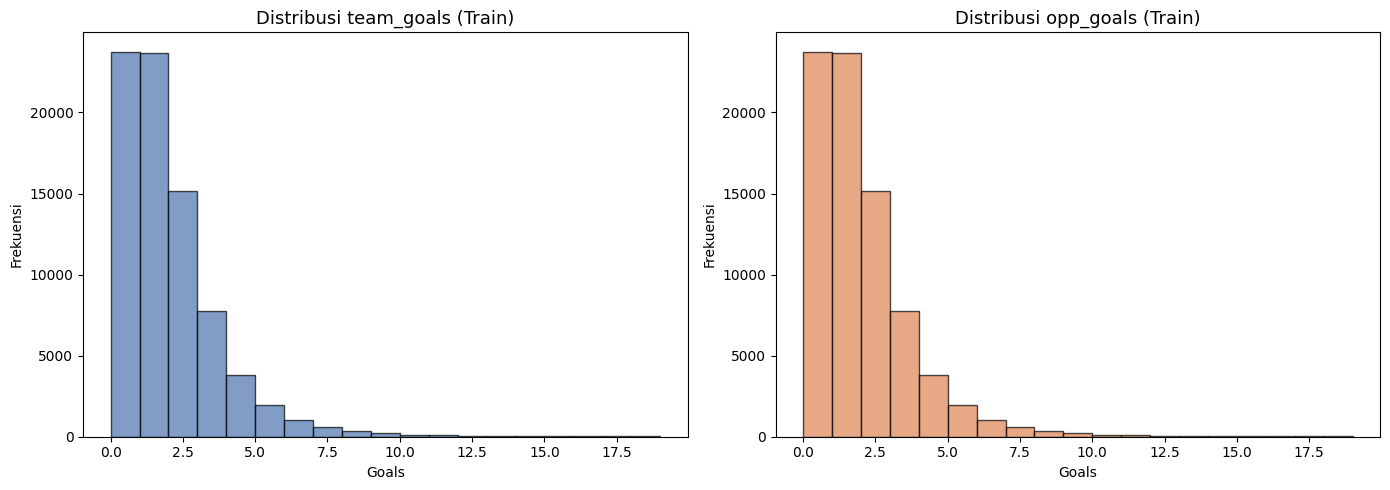

In [42]:
# Distribusi skor (train only)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train["team_goals"].dropna(), bins=range(0, 20), edgecolor="black", alpha=0.7, color="#4C72B0")
axes[0].set_title("Distribusi team_goals (Train)", fontsize=13)
axes[0].set_xlabel("Goals")
axes[0].set_ylabel("Frekuensi")

axes[1].hist(train["opp_goals"].dropna(), bins=range(0, 20), edgecolor="black", alpha=0.7, color="#DD8452")
axes[1].set_title("Distribusi opp_goals (Train)", fontsize=13)
axes[1].set_xlabel("Goals")
axes[1].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

In [43]:
# Top exact scorelines
train["scoreline"] = (
    train["team_goals"].astype(int).astype(str) + "-" +
    train["opp_goals"].astype(int).astype(str)
)
scoreline_counts = train["scoreline"].value_counts().head(20)
print("=== Top 20 Scorelines (Train, row-level) ===")
print(scoreline_counts.to_string())

# Cleanup temporary column
train.drop(columns=["scoreline"], inplace=True)

=== Top 20 Scorelines (Train, row-level) ===
scoreline
1-1    7386
0-1    6382
1-0    6382
0-0    5822
2-1    4903
1-2    4903
0-2    4642
2-0    4642
2-2    3038
3-0    2786
0-3    2786
1-3    2462
3-1    2462
4-0    1592
0-4    1592
2-3    1501
3-2    1501
4-1    1244
1-4    1244
5-0     917


In [44]:
# Teams di test yang tidak ada di train
train_teams = set(train["team"].unique())
test_teams = set(test["team"].unique())

unseen_teams = test_teams - train_teams
print(f"Jumlah team di test yang TIDAK ada di train: {len(unseen_teams)}")
if unseen_teams:
    print(f"Contoh unseen teams: {sorted(unseen_teams)[:20]}")
else:
    print("[INFO] Semua team di test ada di train.")

Jumlah team di test yang TIDAK ada di train: 50
Contoh unseen teams: ['Abkhazia', 'Artsakh', 'Aymara', 'Barawa', 'Biafra', 'Cascadia', 'Chagos Islands', 'Chameria', 'Cilento', 'County of Nice', 'Curacao', 'Darfur', 'Donetsk PR', 'Délvidék', 'Elba Island', 'Ellan Vannin', 'Felvidék', 'Franconia', 'Froya', 'Great Britain']


In [45]:
# Perbandingan proporsi gender dan tournament antara train vs test
print("=== Perbandingan Proporsi Gender ===")
for g in train["gender"].unique():
    pct_train = (train["gender"] == g).mean() * 100
    pct_test = (test["gender"] == g).mean() * 100
    print(f"  {g}: Train={pct_train:.1f}%, Test={pct_test:.1f}%")

print("\n=== Perbandingan Proporsi Top 10 Tournaments ===")
top_tournaments = train["tournament"].value_counts().head(10).index
for t in top_tournaments:
    pct_train = (train["tournament"] == t).mean() * 100
    pct_test = (test["tournament"] == t).mean() * 100
    print(f"  {t:40s}: Train={pct_train:.1f}%, Test={pct_test:.1f}%")

=== Perbandingan Proporsi Gender ===
  M: Train=88.8%, Test=67.1%
  W: Train=11.2%, Test=32.9%

=== Perbandingan Proporsi Top 10 Tournaments ===
  Friendly                                : Train=35.6%, Test=25.8%
  FIFA World Cup qualification            : Train=15.2%, Test=19.2%
  UEFA Euro qualification                 : Train=7.2%, Test=7.6%
  African Cup of Nations qualification    : Train=3.5%, Test=5.1%
  FIFA World Cup                          : Train=2.4%, Test=1.7%
  Copa América                            : Train=2.1%, Test=1.0%
  AFC Asian Cup qualification             : Train=1.6%, Test=1.9%
  Merdeka Tournament                      : Train=1.5%, Test=0.0%
  British Home Championship               : Train=1.3%, Test=0.0%
  African Cup of Nations                  : Train=1.3%, Test=2.0%


### Insight Distribusi

- **Distribution shift** antara train dan test kemungkinan terjadi, terutama pada proporsi turnamen dan periode waktu.
- Ada kemungkinan **unseen teams** di test yang tidak pernah muncul di train — ini perlu ditangani oleh model.
- Distribusi skor cenderung **low-scoring** (mayoritas 0-2 gol per tim), dengan scoreline paling umum seperti 1-0, 1-1, 0-0, 2-1.
- Informasi ini penting untuk memilih baseline (misal: prediksi scoreline yang paling umum) dan desain feature engineering.

## 12. Shared-Features Feasibility Audit

Memisahkan secara tegas fitur yang tersedia di **kedua** dataset (train dan test) vs yang hanya ada di train.  
Ini menjadi jembatan penting ke eksperimen berikutnya, memastikan baseline awal hanya menggunakan fitur yang feasible.

In [46]:
# ID / non-feature columns yang diexclude dari analisis fitur
ID_COLS = {"Id", "match_id"}
TARGET_COLS_SET = {"team_goals", "opp_goals"}

# Kolom yang ada di kedua dataset (exclude ID dan target)
shared_feature_cols = sorted([
    c for c in (train_cols & test_cols)
    if c not in ID_COLS and c not in TARGET_COLS_SET
])

# Kolom yang hanya ada di train (exclude ID dan target)
train_only_feature_cols = sorted([
    c for c in (train_cols - test_cols)
    if c not in ID_COLS and c not in TARGET_COLS_SET
])

print(f"Shared feature columns ({len(shared_feature_cols)}):")
for i, c in enumerate(shared_feature_cols, 1):
    dtype = str(train[c].dtype)
    print(f"  {i:2d}. {c:35s} ({dtype})")

print(f"\nTrain-only feature columns ({len(train_only_feature_cols)}):")
for i, c in enumerate(train_only_feature_cols, 1):
    dtype = str(train[c].dtype)
    print(f"  {i:2d}. {c:35s} ({dtype})")

Shared feature columns (18):
   1. altitude_venue                      (float64)
   2. confederation_opp                   (str)
   3. confederation_team                  (str)
   4. date                                (datetime64[us])
   5. distance_travel_opp                 (float64)
   6. distance_travel_team                (float64)
   7. gdp_per_capita_opp                  (float64)
   8. gdp_per_capita_team                 (float64)
   9. gender                              (str)
  10. is_home                             (int64)
  11. neutral                             (int64)
  12. opponent                            (str)
  13. population_opp                      (float64)
  14. population_team                     (float64)
  15. team                                (str)
  16. temperature_venue                   (float64)
  17. tournament                          (str)
  18. venue_country                       (str)

Train-only feature columns (25):
   1. days_since_last_matc

In [47]:
# Cetak ringkasan
print("=" * 50)
print("RINGKASAN")
print("=" * 50)
print(f"Total shared features    : {len(shared_feature_cols)}")
print(f"Total train-only features: {len(train_only_feature_cols)}")
print(f"Total target columns     : {len(TARGET_COLS_SET)}")
print(f"Total ID columns         : {len(ID_COLS)}")

RINGKASAN
Total shared features    : 18
Total train-only features: 25
Total target columns     : 2
Total ID columns         : 2


### Implikasi untuk Eksperimen Berikutnya

1. **Baseline awal harus feasible** hanya dengan `shared_feature_cols` — ini adalah fitur yang tersedia saat inference di test.
2. **Train-only features** (Elo, ranking, form, H2H, dll.) sangat informatif tetapi tidak tersedia di test. Eksperimen lanjutan perlu strategi khusus:
   - Feature engineering yang mereproduksi informasi serupa dari data yang tersedia.
   - Atau pendekatan lain yang tidak bergantung pada fitur ini saat inference.
3. **Jangan membuat validasi yang terlalu optimistis** dengan menggunakan train-only features — skor validasi akan drop dramatis saat inference test.

## 13. Baseline Sanity Check

Tujuan section ini **bukan** mengejar skor bagus, melainkan memastikan **seluruh pipeline** (evaluator, split, reverse mapping) bekerja tanpa error.

### Baseline yang digunakan:
1. **Prediksi 1-1** untuk semua pertandingan.
2. **Prediksi median global** dari skor train.
3. **Prediksi scoreline paling umum** dari train fold.

In [48]:
# Baseline 1: Prediksi semua 1-1
valid_fold_b1 = valid_fold.copy()
valid_fold_b1["pred_a"] = 1
valid_fold_b1["pred_b"] = 1

awmae_b1 = awmae_score(
    valid_fold_b1["team_a_goals"],
    valid_fold_b1["team_b_goals"],
    valid_fold_b1["pred_a"],
    valid_fold_b1["pred_b"],
    valid_fold_b1["tournament"],
)
print(f"Baseline 1 (Prediksi semua 1-1):      AW-MAE = {awmae_b1:.6f}")

Baseline 1 (Prediksi semua 1-1):      AW-MAE = 4.662228


In [49]:
# Baseline 2: Prediksi median global
median_a = int(round(train_fold["team_a_goals"].median()))
median_b = int(round(train_fold["team_b_goals"].median()))
print(f"Median skor train fold: team_a={median_a}, team_b={median_b}")

valid_fold_b2 = valid_fold.copy()
valid_fold_b2["pred_a"] = median_a
valid_fold_b2["pred_b"] = median_b

awmae_b2 = awmae_score(
    valid_fold_b2["team_a_goals"],
    valid_fold_b2["team_b_goals"],
    valid_fold_b2["pred_a"],
    valid_fold_b2["pred_b"],
    valid_fold_b2["tournament"],
)
print(f"Baseline 2 (Prediksi median {median_a}-{median_b}):   AW-MAE = {awmae_b2:.6f}")

Median skor train fold: team_a=1, team_b=1
Baseline 2 (Prediksi median 1-1):   AW-MAE = 4.662228


In [50]:
# Baseline 3: Prediksi scoreline paling umum dari train fold
scorelines = list(zip(
    train_fold["team_a_goals"].astype(int),
    train_fold["team_b_goals"].astype(int),
))
most_common = Counter(scorelines).most_common(5)
print("Top 5 scorelines di train fold (match-level canonical):")
for sl, cnt in most_common:
    print(f"  {sl[0]}-{sl[1]}: {cnt} matches")

top_scoreline = most_common[0][0]
print(f"\nScoreline paling umum: {top_scoreline[0]}-{top_scoreline[1]}")

valid_fold_b3 = valid_fold.copy()
valid_fold_b3["pred_a"] = top_scoreline[0]
valid_fold_b3["pred_b"] = top_scoreline[1]

awmae_b3 = awmae_score(
    valid_fold_b3["team_a_goals"],
    valid_fold_b3["team_b_goals"],
    valid_fold_b3["pred_a"],
    valid_fold_b3["pred_b"],
    valid_fold_b3["tournament"],
)
print(f"Baseline 3 (Scoreline {top_scoreline[0]}-{top_scoreline[1]}):       AW-MAE = {awmae_b3:.6f}")

Top 5 scorelines di train fold (match-level canonical):


  1-1: 2978 matches
  1-0: 2495 matches
  0-1: 2494 matches
  0-0: 2292 matches
  1-2: 1986 matches

Scoreline paling umum: 1-1
Baseline 3 (Scoreline 1-1):       AW-MAE = 4.662228


In [51]:
# Ringkasan baseline
print("=" * 55)
print("RINGKASAN BASELINE SANITY CHECK")
print("=" * 55)
print(f"{'Baseline':<40s} {'AW-MAE':>10s}")
print("-" * 55)
print(f"{'1. Prediksi semua 1-1':<40s} {awmae_b1:>10.6f}")
print(f"{'2. Prediksi median global':<40s} {awmae_b2:>10.6f}")
print(f"{'3. Prediksi scoreline terumum':<40s} {awmae_b3:>10.6f}")

RINGKASAN BASELINE SANITY CHECK
Baseline                                     AW-MAE
-------------------------------------------------------
1. Prediksi semua 1-1                      4.662228
2. Prediksi median global                  4.662228
3. Prediksi scoreline terumum              4.662228


In [52]:
# Contoh prediksi vs aktual (Baseline 1)
print("=== Contoh Prediksi vs Aktual (Baseline 1: 1-1) ===")
sample = valid_fold.head(10)[["match_id", "team_a", "team_b",
                               "team_a_goals", "team_b_goals",
                               "tournament"]].copy()
sample["pred_a"] = 1
sample["pred_b"] = 1
sample["loss"] = [
    official_match_loss(
        row["team_a_goals"], row["team_b_goals"],
        row["pred_a"], row["pred_b"],
    )
    for _, row in sample.iterrows()
]
display(sample)

=== Contoh Prediksi vs Aktual (Baseline 1: 1-1) ===


,match_id,team_a,team_b,team_a_goals,team_b_goals,tournament,pred_a,pred_b,loss
0,W002556,Australia,Russia,5,0,Four Nations Tournament,1,1,10.5163
1,W002557,China PR,Germany,0,2,Four Nations Tournament,1,1,4.0720
2,M028954,Haiti,Trinidad and Tobago,0,1,Friendly,1,1,2.4150
3,M028956,Japan,Syria,3,0,Friendly,1,1,5.9947
4,M028959,Bahrain,Lebanon,2,1,Friendly,1,1,2.4150
5,M028958,Hungary,Saudi Arabia,0,0,Friendly,1,1,1.4822
6,M028957,Bosnia and Herzegovina,Iran,1,2,Friendly,1,1,2.4150
7,M028955,Kuwait,North Korea,0,0,Friendly,1,1,1.4822
8,M028960,Haiti,Trinidad and Tobago,1,2,Friendly,1,1,2.4150
9,M028961,Egypt,South Korea,1,0,Friendly,1,1,2.4150


### Catatan Baseline

- Baseline ini **hanya sanity check** — tujuan utamanya memastikan semua komponen pipeline (evaluator, split, scoring) berjalan tanpa error.
- Skor yang dihasilkan **bukan performa final** dan akan di-improve di eksperimen berikutnya.
- Pipeline evaluasi berjalan sukses end-to-end: dari split temporal → prediksi → perhitungan AW-MAE.

## 14. Ringkasan Hasil Eksperimen EXP 00

### Temuan Utama

1. **Dataset berhasil dibaca** — Seluruh file (train, test, sample submission, metadata) berhasil di-load tanpa error.
2. **Representasi 2 rows per match terverifikasi** — Setiap `match_id` memiliki tepat 2 baris dengan konsistensi team/opponent, date, tournament, dan skor.
3. **Canonicalization match-level berhasil** — Data row-level berhasil dikonversi ke representasi 1 row per match dengan aturan deterministik (alfabet).
4. **Reverse mapping ke submission berhasil** — Prediksi match-level dapat dikonversi ke format submission row-level yang valid.
5. **Evaluator AW-MAE berhasil diimplementasikan** — Termasuk penalty (exact, outcome, GD), multiplier, non-linear scaling, dan tournament weighting.
6. **Temporal validation berhasil disiapkan** — Split berbasis tanggal tanpa leakage dan overlap match_id.
7. **Train-test feature gap teridentifikasi** — 27 fitur performa historis hanya tersedia di train.
8. **Baseline sanity check berhasil** — Pipeline evaluasi berjalan end-to-end tanpa error.

### Infrastruktur yang Tersedia

| Helper Function | Deskripsi |
|---|---|
| `seed_everything()` | Set seed untuk reproducibility |
| `validate_input_files()` | Validasi keberadaan file input |
| `summarize_dataframe()` | Ringkasan tipe data dan missing values |
| `audit_match_pairing()` | Audit konsistensi 2-row-per-match |
| `build_match_level()` | Konversi row-level → match-level |
| `match_predictions_to_submission()` | Konversi match-level → submission |
| `_outcome()` / `get_tournament_weight()` | Helper metrik |
| `official_match_loss()` | Loss per pertandingan |
| `awmae_score()` | Skor AW-MAE keseluruhan |
| `make_time_based_holdout()` | Temporal validation split |

## 15. Next Step ke EXP 01

Eksperimen berikutnya (**EXP 01**) akan fokus pada:

1. **Baseline model awal** yang hanya menggunakan **shared features** (fitur yang tersedia di train dan test).
2. Representasi **match-level** yang sudah dibangun di EXP 00.
3. **Temporal validation** dengan split yang sama atau serupa.
4. Evaluasi menggunakan **offline AW-MAE** yang sudah diimplementasikan.
5. Mulai membangun fondasi model yang **feasible terhadap test set** — artinya tidak bergantung pada fitur yang hanya ada di train.

### Prioritas EXP 01
- Eksplorasi model sederhana (misalnya regression, gradient boosting ringan).
- Feature encoding yang tepat untuk fitur kategorikal (tournament, country, confederation).
- Validasi bahwa skor AW-MAE lebih baik daripada baseline naif.

---

*EXP 00 selesai. Fondasi pipeline kompetisi telah dibangun.*